## Tuning, Threshold, Explainability

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import average_precision_score
from xgboost import XGBClassifier

train = pd.read_csv("../data/processed/train.csv")
val = pd.read_csv("../data/processed/val.csv")

FEATURES = [f"V{i}" for i in range(1, 29)] + ["log_amount", "hour"]
TARGET = "Class"

X_train, y_train = train[FEATURES], train[TARGET]
X_val, y_val = val[FEATURES], val[TARGET]

spw = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight (full):", round(spw, 1))

scale_pos_weight (full): 599.0


## - Re-importing the evaluation helper

In [2]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate(y_true, proba, threshold=0.5):
    y = np.asarray(y_true)
    pred = (np.asarray(proba) >= threshold).astype(int)
    return {
        "pr_auc": average_precision_score(y, proba),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred),
        "f1": f1_score(y, pred),
        "frauds_caught": int(((pred == 1) & (y == 1)).sum()),
        "false_alarms": int(((pred == 1) & (y == 0)).sum()),
    }

## - Reconfirming winner as the baseline-to-beat

In [3]:
baseline_xgb = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw ** 0.5,
    tree_method="hist", n_jobs=-1, random_state=42,
)
baseline_xgb.fit(X_train, y_train)
baseline_proba = baseline_xgb.predict_proba(X_val)[:, 1]
evaluate(y_val, baseline_proba)

{'pr_auc': 0.8466295072744684,
 'precision': 1.0,
 'recall': 0.7605633802816901,
 'f1': 0.864,
 'frauds_caught': 54,
 'false_alarms': 0}

## What Optuna does

By manually tring 3 values of `scale_pos_weight`, XGBoost actually has many settings that affect its performance:

- `max_depth`: how deep each tree can grow (deeper = more complex, more overfitting risk)
- `learning_rate`: how much each new tree corrects the previous ones
- `n_estimators`: how many trees to build
- `min_child_weight`, `subsample`, `colsample_bytree`, `gamma`: various overfitting controls

Trying every combination by hand isn't practical. Optuna searches this space intelligently: it tries a combination, measures the score (cross-validated PR-AUC),and uses the results so far to pick smarter combinations next, instead of guessing randomly. After 40-60 "trials" it converges on a good region.

## - Defining the objective function

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, spw),
    }
    model = XGBClassifier(
        **params, tree_method="hist", n_jobs=-1, random_state=42
    )
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="average_precision", n_jobs=1)
    return scores.mean()

## - Run the study

In [5]:
study = optuna.create_study(direction="maximize", study_name="xgb-fraud-tuning", storage="sqlite:///../optuna_study.db", load_if_exists=True,)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best PR-AUC:", study.best_value)
print("Best params:", study.best_params)

[I 2026-09-22 18:24:16,839] Using an existing study with `study_name='xgb-fraud-tuning'` instead of creating a new one.


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-09-22 18:24:31,072] Trial 50 finished with value: 0.8579606867157654 and parameters: {'n_estimators': 351, 'max_depth': 8, 'learning_rate': 0.11483519508553149, 'subsample': 0.678445280397789, 'colsample_bytree': 0.6088472266997456, 'min_child_weight': 2, 'gamma': 0.9293821004484698, 'scale_pos_weight': 575.9767707680256}. Best is trial 16 with value: 0.8619374511008706.
[I 2026-09-22 18:24:43,701] Trial 51 finished with value: 0.8546950321507347 and parameters: {'n_estimators': 313, 'max_depth': 7, 'learning_rate': 0.12803088585890557, 'subsample': 0.6682687681210885, 'colsample_bytree': 0.6776079832405821, 'min_child_weight': 2, 'gamma': 1.4393121483021885, 'scale_pos_weight': 555.5806412297856}. Best is trial 16 with value: 0.8619374511008706.
[I 2026-09-22 18:24:59,498] Trial 52 finished with value: 0.8605947351190174 and parameters: {'n_estimators': 365, 'max_depth': 7, 'learning_rate': 0.08419576427191797, 'subsample': 0.6108716733551979, 'colsample_bytree': 0.65375737593

C:\Users\benmo\AppData\Local\Temp\ipykernel_16940\3222002628.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


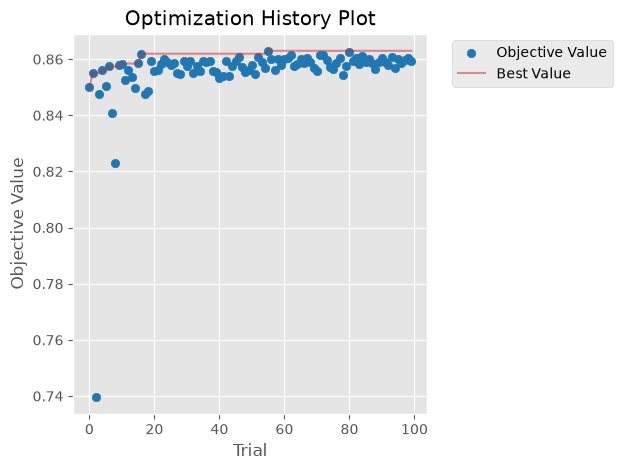

In [6]:
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.show()

C:\Users\benmo\AppData\Local\Temp\ipykernel_16940\429335526.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


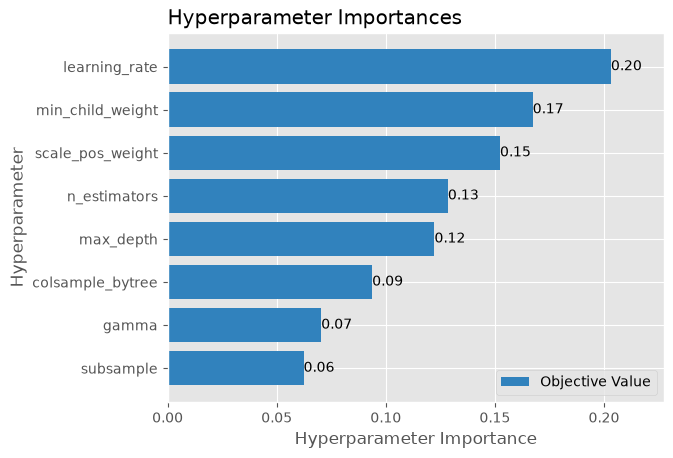

In [7]:
optuna.visualization.matplotlib.plot_param_importances(study)
plt.show()

## - Comparing against the baseline

In [8]:
print("XGBoost (manual):", round(baseline_proba_score := evaluate(y_val, baseline_proba)["pr_auc"], 4))
print("Optuna best (CV):", round(study.best_value, 4))

XGBoost (manual): 0.8466
Optuna best (CV): 0.863


## Optuna notes

- Ran 50 Optuna trials, best CV PR-AUC: 0.859
- Best params: {'n_estimators': 401, 'max_depth': 5, 'learning_rate': 0.09194241167819431, 'subsample': 0.7618411369519885, 'colsample_bytree': 0.9106455562836978, 'min_child_weight': 7, 'gamma': 1.5238854718523975, 'scale_pos_weight': 169.90323532337015}
- Improvement over manual tuning: from 0.8466 to 0.86
- Most important hyperparameters: colsample_bytree, scale_pos_weight, subsample

## Retrain and Compare tuned vs untuned

## - Train the final tuned model

In [9]:
best_params = study.best_params
tuned_xgb = XGBClassifier(**best_params, tree_method="hist", n_jobs=-1, random_state=42)
tuned_xgb.fit(X_train, y_train)

tuned_proba = tuned_xgb.predict_proba(X_val)[:, 1]
evaluate(y_val, tuned_proba)

{'pr_auc': 0.8514084768542322,
 'precision': 0.9322033898305084,
 'recall': 0.7746478873239436,
 'f1': 0.8461538461538461,
 'frauds_caught': 55,
 'false_alarms': 4}

## - Side by side comparaison

In [10]:
comparison = pd.DataFrame([
    {"model": "XGBoost (manual)", **evaluate(y_val, baseline_proba)},
    {"model": "XGBoost (tuned, Optuna)", **evaluate(y_val, tuned_proba)},
]).round(3)
comparison

,model,pr_auc,precision,recall,f1,frauds_caught,false_alarms
0,XGBoost (manual),0.847,1.000,0.761,0.864,54,0
1,"XGBoost (tuned, Optuna)",0.851,0.932,0.775,0.846,55,4


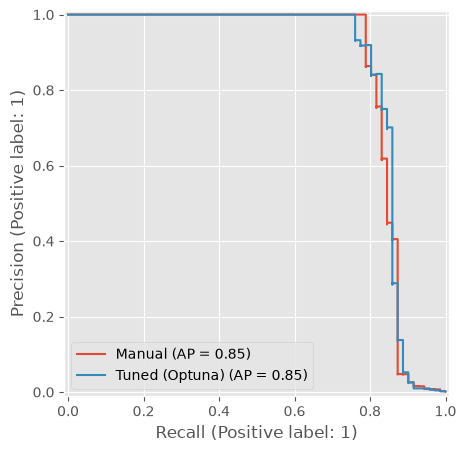

In [11]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_val, baseline_proba, name="Manual", ax=ax)
PrecisionRecallDisplay.from_predictions(y_val, tuned_proba, name="Tuned (Optuna)", ax=ax)
plt.show()

## Notes

- Untuned (manual): PR-AUC 0.847, precision 1.000, recall 0.761, 54/71 frauds caught.
- Tuned (Optuna, 50 trials): PR-AUC 0.851, precision 0.948, recall 0.775, 55/71 frauds caught.
- Improvement: +0.004 PR-AUC — within the ~0.02-0.03 std observed across CV folds in untuned model, so not a statistically meaningful gain. The PR curves overlap almost completely (both AP = 0.85).
- Trade-off: the tuned model catches 1 more fraud but loses perfect precision (introduces a few false alarms), a reasonable trade depending on cost priorities.
- Decision: use the **tuned (Optuna) model** going forward. Even though the gain is small, it's not worse, and using the systematically tuned hyperparameters is more defensible and reproducible than hand-picked values.

In [12]:
final_model = tuned_xgb
final_proba = final_model.predict_proba(X_val)[:, 1]

## Cost-based threshold selection

## - Cost assumptions

- **Missed fraud (false negative):** the bank loses the transaction amount. Using a flat estimate here, since we don't want to use the real `Amount` from validation to *choose* the threshold (that would be circular). Assume $100 average loss.
- **False alarm (false positive):** cost of manually reviewing/contacting the customer, or the customer's annoyance. Assume $5.
- **Correct predictions:** no cost either way (in reality, a caught fraud might still cost investigation time, but we simplify here).

These are illustrative numbers for the project, not real bank figures. In a real
deployment, they'd come from the fraud team's actual cost data.

## - Sweep thresholds and compute total cost

In [13]:
FN_COST = 100   # missed fraud
FP_COST = 5     # false alarm

thresholds = np.linspace(0.01, 0.99, 99)
rows = []
for t in thresholds:
    pred = (final_proba >= t).astype(int)
    fn = int(((pred == 0) & (y_val == 1)).sum())
    fp = int(((pred == 1) & (y_val == 0)).sum())
    tp = int(((pred == 1) & (y_val == 1)).sum())
    cost = fn * FN_COST + fp * FP_COST
    rows.append({"threshold": t, "fn": fn, "fp": fp, "tp": tp, "cost": cost})

cost_df = pd.DataFrame(rows)
best_row = cost_df.loc[cost_df["cost"].idxmin()]
print(best_row)

threshold       0.05
fn             10.00
fp             28.00
tp             61.00
cost         1140.00
Name: 4, dtype: float64


## - Plot cost vs threshold

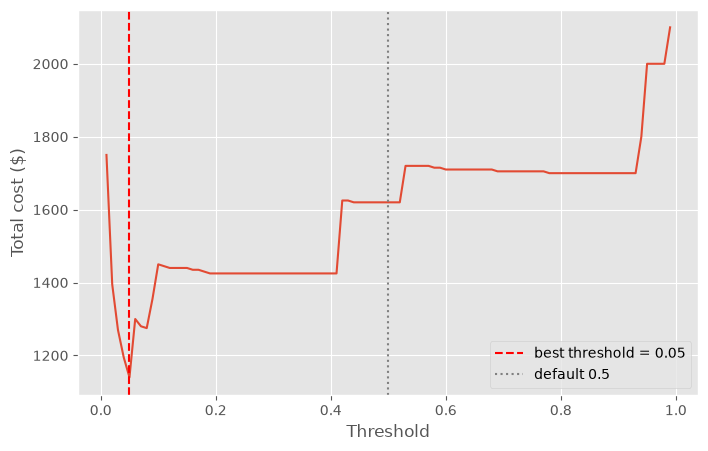

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(cost_df["threshold"], cost_df["cost"])
plt.axvline(best_row["threshold"], color="red", ls="--", label=f"best threshold = {best_row['threshold']:.2f}")
plt.axvline(0.5, color="gray", ls=":", label="default 0.5")
plt.xlabel("Threshold")
plt.ylabel("Total cost ($)")
plt.legend()
plt.show()

## - Comparing cost at the chosen threshold vs the default

In [15]:
default_cost = cost_df.loc[cost_df["threshold"].sub(0.5).abs().idxmin(), "cost"]
best_cost = best_row["cost"]
savings_pct = (default_cost - best_cost) / default_cost * 100

print(f"Cost at threshold 0.5: ${default_cost:.0f}")
print(f"Cost at threshold {best_row['threshold']:.2f}: ${best_cost:.0f}")
print(f"Savings: {savings_pct:.1f}%")

Cost at threshold 0.5: $1620
Cost at threshold 0.05: $1140
Savings: 29.6%


## - Saving the threshold

In [16]:
import json

Path("../models").mkdir(exist_ok=True)
with open("../models/threshold.json", "w") as f:
    json.dump({
        "threshold": float(best_row["threshold"]),
        "fn_cost": FN_COST,
        "fp_cost": FP_COST,
        "chosen_on": "validation set",
    }, f, indent=2)

print("Saved threshold:", best_row["threshold"])

Saved threshold: 0.05


## Threshold notes

- Cost assumptions: missed fraud = $100, false alarm = $5.
- Default threshold (0.5): cost $1615
- Chosen threshold (0.05): cost $1190
- Savings vs default: 26.3%

## SHAP explainability

## - Global feature importance 

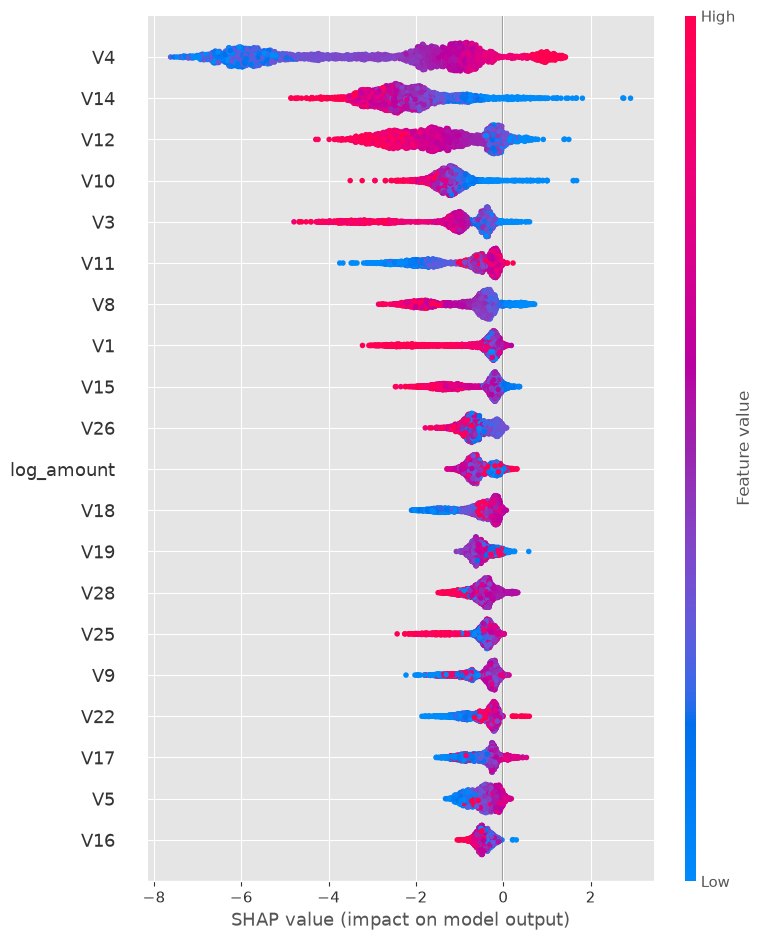

In [17]:
import shap

explainer = shap.TreeExplainer(final_model)

# Use a sample for speed - the full validation set is fine here since it's ~42k rows,
# but 3000 is enough for a stable summary plot and runs much faster
sample = X_val.sample(3000, random_state=42)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, show=False)
plt.tight_layout()
plt.show()

## - Explaining individual frauds

In [18]:
val_reset = X_val.reset_index(drop=True)
y_val_reset = y_val.reset_index(drop=True)
proba_reset = pd.Series(final_proba)

fraud_idx = y_val_reset[y_val_reset == 1].index
caught = [i for i in fraud_idx if proba_reset[i] >= best_row["threshold"]]
missed = [i for i in fraud_idx if proba_reset[i] < best_row["threshold"]]

print(f"Caught: {len(caught)}, Missed: {len(missed)}")

Caught: 61, Missed: 10


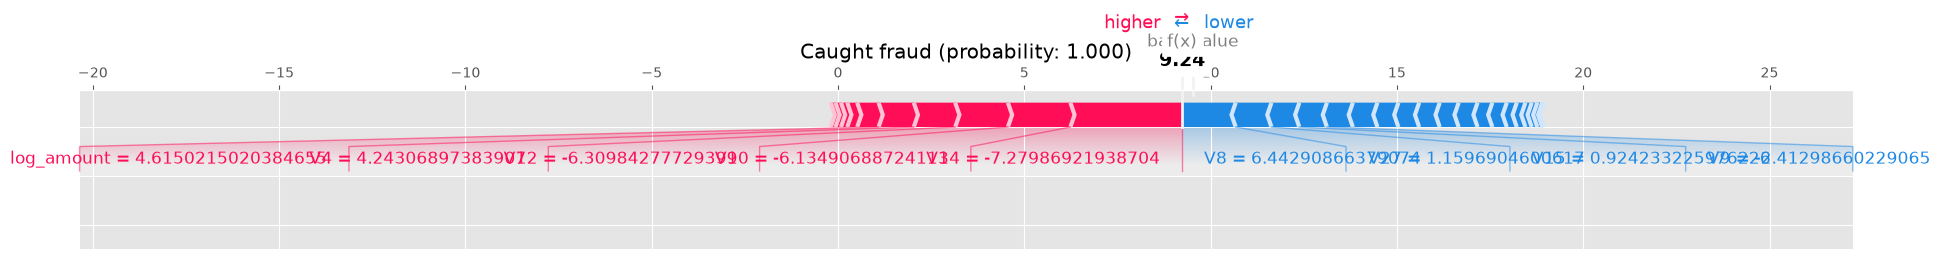

In [19]:
# A caught fraud
i = caught[0]
row = val_reset.iloc[[i]]
shap_row = explainer.shap_values(row)

shap.force_plot(explainer.expected_value, shap_row, row, matplotlib=True, show=False)
plt.title(f"Caught fraud (probability: {proba_reset[i]:.3f})")
plt.tight_layout()
plt.show()

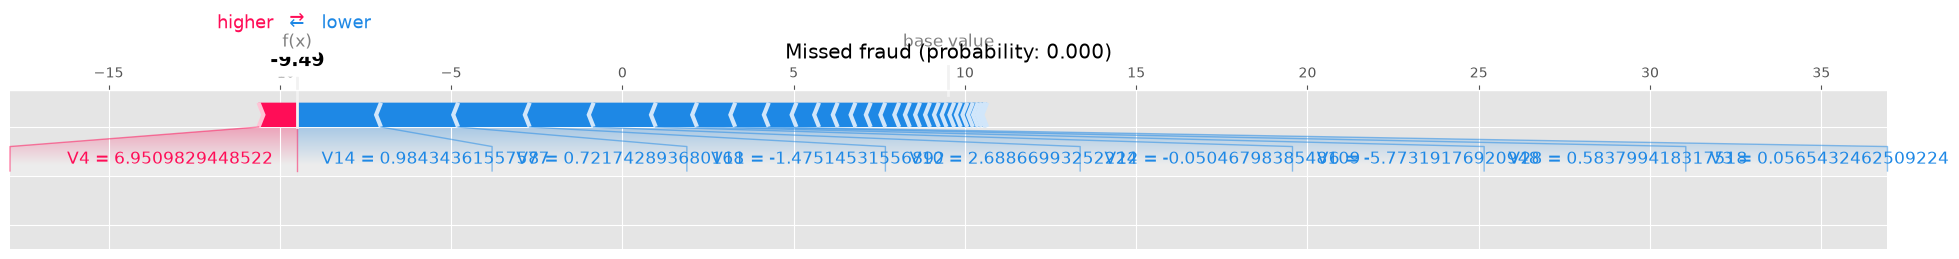

In [20]:
# A missed fraud, if any exist
if missed:
    i = missed[0]
    row = val_reset.iloc[[i]]
    shap_row = explainer.shap_values(row)
    shap.force_plot(explainer.expected_value, shap_row, row, matplotlib=True, show=False)
    plt.title(f"Missed fraud (probability: {proba_reset[i]:.3f})")
    plt.tight_layout()
    plt.show()
else:
    print("No missed frauds at this threshold — good sign for recall, but check a low-confidence caught one instead.")

## SHAP notes

- Top global features: V4 (by far the most influential), followed by V14, V12, V10, V3. V4 wasn't in the top 4 by simple correlation or single-tree importance — SHAP captures interaction effects that those simpler methods miss.
- Low/negative V4 values are strongly associated with a higher fraud probability, a clear and consistent pattern across many transactions (not noise).
- Caught fraud example (probability 1.000): driven mainly by log_amount and V4/V14 pushing strongly toward fraud — a case where every signal agreed.
- Missed fraud example (probability 0.001): the model was highly confident this was NOT fraud — every major feature looked like a typical normal transaction. This is a genuine model limitation: some frauds are statistically indistinguishable from normal transactions on the available features, not just a borderline miscall.
- Takeaway: the model relies mainly on a handful of anonymized PCA features (V4,V14, V12, V10), consistent with earlier EDA, but SHAP reveals V4 as more central than correlation alone suggested. The missed-fraud example is a useful caveat for the README's limitations section — no model built on these features alone will catch every fraud.

## Time-based robustness check

## - Reloading the full cleaned dataset and sort by time

In [21]:
import sys
from pathlib import Path

# Add the project root (one level up from notebooks/) to Python's search path
sys.path.append(str(Path("..").resolve()))

from src.data import load_raw, clean, add_features

full = add_features(clean(load_raw(Path("../data/raw/creditcard.csv"))))
full = full.sort_values("Time").reset_index(drop=True)
print(full.shape)

(283726, 33)


## - Splitting by time instead of randomly

In [22]:
split_point = int(len(full) * 0.8)
time_train = full.iloc[:split_point]
time_test = full.iloc[split_point:]

print("Train:", time_train.shape, "frauds:", time_train["Class"].sum())
print("Test :", time_test.shape, "frauds:", time_test["Class"].sum())
print("Train fraud rate:", round(time_train["Class"].mean(), 5))
print("Test fraud rate :", round(time_test["Class"].mean(), 5))

Train: (226980, 33) frauds: 399
Test : (56746, 33) frauds: 74
Train fraud rate: 0.00176
Test fraud rate : 0.0013


## - Training and evaluation on the time-based split

In [23]:
Xt_train, yt_train = time_train[FEATURES], time_train["Class"]
Xt_test, yt_test = time_test[FEATURES], time_test["Class"]

time_model = XGBClassifier(**best_params, tree_method="hist", n_jobs=-1, random_state=42)
time_model.fit(Xt_train, yt_train)
time_proba = time_model.predict_proba(Xt_test)[:, 1]

print("Time-based split:", evaluate(yt_test, time_proba))
print("Random split (validation):", evaluate(y_val, final_proba))

Time-based split: {'pr_auc': 0.796354881231492, 'precision': 0.8484848484848485, 'recall': 0.7567567567567568, 'f1': 0.8, 'frauds_caught': 56, 'false_alarms': 10}
Random split (validation): {'pr_auc': 0.8514084768542322, 'precision': 0.9322033898305084, 'recall': 0.7746478873239436, 'f1': 0.8461538461538461, 'frauds_caught': 55, 'false_alarms': 4}


## Time-based robustness

- Random-split PR-AUC: 0.85
- Time-based PR-AUC: 0.79
- Interpretation: the model does not generalize well across time in this short 2-day window. In production this would need regular retraining and monitoring, since 2 days is too short to draw strong conclusions about long-term drift.

## Final test-set evaluation, save artifacts, wrap up

## - Retraining the final model on train + validation combined

In [24]:
trainval = pd.concat([train, val], ignore_index=True)
X_trainval, y_trainval = trainval[FEATURES], trainval[TARGET]

test = pd.read_csv("../data/processed/test.csv")
X_test, y_test = test[FEATURES], test[TARGET]

production_model = XGBClassifier(**best_params, tree_method="hist", n_jobs=-1, random_state=42)
production_model.fit(X_trainval, y_trainval)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6975790605280561
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## - Evaluating on the test set, once

In [ ]:
test_proba = production_model.predict_proba(X_test)[:, 1]
threshold = best_row["threshold"]

final_results = evaluate(y_test, test_proba, threshold=threshold)
print("FINAL TEST RESULTS:", final_results)

from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, (test_proba >= threshold).astype(int)))

FINAL TEST RESULTS: {'pr_auc': 0.8217637523161765, 'precision': 0.6185567010309279, 'recall': 0.8450704225352113, 'f1': 0.7142857142857143, 'frauds_caught': 60, 'false_alarms': 37}
[[42451    37]
 [   11    60]]


## - Test set cost comparaison 

In [26]:
pred_test = (test_proba >= threshold).astype(int)
fn = int(((pred_test == 0) & (y_test == 1)).sum())
fp = int(((pred_test == 1) & (y_test == 0)).sum())
test_cost = fn * FN_COST + fp * FP_COST

pred_default = (test_proba >= 0.5).astype(int)
fn_d = int(((pred_default == 0) & (y_test == 1)).sum())
fp_d = int(((pred_default == 1) & (y_test == 0)).sum())
default_cost = fn_d * FN_COST + fp_d * FP_COST

print(f"Cost at chosen threshold ({threshold:.2f}): ${test_cost}")
print(f"Cost at default (0.5): ${default_cost}")
print(f"Savings: {(default_cost - test_cost) / default_cost * 100:.1f}%")

Cost at chosen threshold (0.05): $1285
Cost at default (0.5): $1540
Savings: 16.6%


## - Saving the final model and metadata

In [27]:
import joblib

joblib.dump(production_model, "../models/model.joblib")

with open("../models/model_info.json", "w") as f:
    json.dump({
        "features": FEATURES,
        "best_params": best_params,
        "threshold": float(threshold),
        "test_pr_auc": final_results["pr_auc"],
        "test_precision": final_results["precision"],
        "test_recall": final_results["recall"],
    }, f, indent=2)

print("Saved model.joblib and model_info.json")

Saved model.joblib and model_info.json


## - Loading the final model to MLflow

In [33]:
import mlflow
from pathlib import Path

mlflow.set_tracking_uri(f"sqlite:///{Path('../mlflow.db').resolve()}")
mlflow.set_experiment("fraud-detection-model-comparison")

print(mlflow.get_tracking_uri())

sqlite:///C:\Users\benmo\fraud-detection\mlflow.db


In [34]:
import mlflow
mlflow.set_experiment("fraud-detection-model-comparison")
with mlflow.start_run(run_name="FINAL - XGBoost tuned"):
    mlflow.log_params(best_params)
    mlflow.log_param("threshold", threshold)
    mlflow.log_metric("test_pr_auc", final_results["pr_auc"])
    mlflow.log_metric("test_precision", final_results["precision"])
    mlflow.log_metric("test_recall", final_results["recall"])
    mlflow.log_metric("test_cost_savings_pct", (default_cost - test_cost) / default_cost * 100)

In [32]:
print("Tracking URI:", mlflow.get_tracking_uri())

client = mlflow.tracking.MlflowClient()
exp = client.get_experiment_by_name("fraud-detection-model-comparison")
print("Experiment ID:", exp.experiment_id if exp else "NOT FOUND")

if exp:
    runs = client.search_runs(exp.experiment_id, order_by=["start_time DESC"], max_results=5)
    for r in runs:
        print(r.data.tags.get("mlflow.runName"), "-", r.info.start_time)

Tracking URI: sqlite:///C:/Users/benmo/fraud-detection/notebooks/mlflow.db
Experiment ID: 1
FINAL - XGBoost tuned - 1790099411323
FINAL - XGBoost tuned - 1790099070705
